In [1]:
import torch
from torch import nn
import torchvision as tv
import matplotlib.pyplot as plt
import time

In [2]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(device)

cuda


In [3]:
def evaluate_accuracy(data_iter, net):
    acc_sum, n = 0, 0
    net.eval()

    for X, y in data_iter:
        X, y = X.to(device), y.to(device)
        acc_sum += (net(X).argmax(axis=1) == y).sum()
        n += y.shape[0]

    return acc_sum.item() / n

In [4]:
def train(net, train_iter, test_iter, trainer, num_epochs):
    loss = nn.CrossEntropyLoss()

    net.to(device)

    loss_history = []

    for epoch in range(num_epochs):

        net.train()

        train_l_sum, n = 0, 0
        start = time.time()

        for i, (X, y) in enumerate(train_iter):
            X, y = X.to(device), y.to(device)

            trainer.zero_grad()

            y_hat = net(X)

            l = loss(y_hat, y)

            l.backward()

            trainer.step()

            train_l_sum += l.item()
            n += y.shape[0]

        epoch_loss = train_l_sum / len(train_iter)
        loss_history.append(epoch_loss)

        test_acc = evaluate_accuracy(test_iter, net)

        print(f'epoch {epoch + 1}, loss {epoch_loss:.4f}, test acc {test_acc:.3f}, time {time.time() - start:.1f}')

    return loss_history

In [5]:
BATCH_SIZE = 16

transforms = tv.transforms.Compose([
    tv.transforms.Resize((224,224)),
    tv.transforms.Grayscale(3),
    tv.transforms.ToTensor()
])

train_dataset = tv.datasets.EMNIST(
    '.',
    split='balanced',
    train=True,
    download=True,
    transform=transforms
)

test_dataset = tv.datasets.EMNIST(
    '.',
    split='balanced',
    train=False,
    download=True,
    transform=transforms
)

train_iter = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_iter = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [6]:
out_features = len(train_dataset.classes)
out_features

47

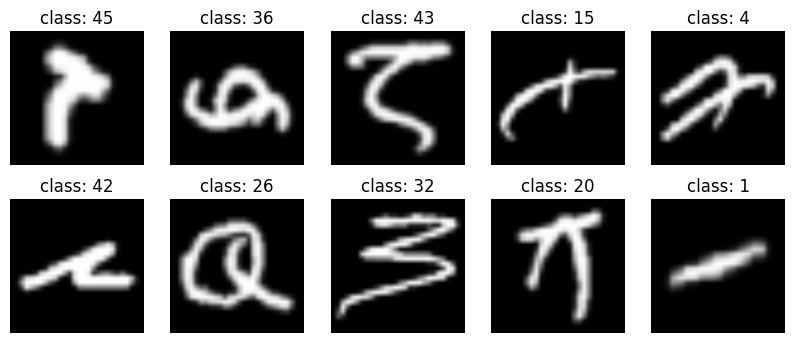

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))

for i in range(10):
    img, label = train_dataset[i]

    ax = axes[i // 5, i % 5]

    ax.imshow(img[0], cmap='gray')
    ax.set_title(f'class: {label}')
    ax.axis('off')

plt.show()

In [8]:
print(train_dataset.classes)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']


In [9]:
model_resnet = tv.models.resnet18(weights=None)

model_resnet.fc = nn.Linear(
    model_resnet.fc.in_features,
    out_features
)

trainer = torch.optim.Adam(model_resnet.parameters(), lr=0.001)

resnet_loss = train(
    model_resnet,
    train_iter,
    test_iter,
    trainer,
    num_epochs=2
)

epoch 1, loss 0.5510, test acc 0.865, time 256.3
epoch 2, loss 0.3469, test acc 0.881, time 257.8


In [10]:
model_vgg = tv.models.vgg16(weights=None)

model_vgg.classifier[6] = nn.Linear(
    model_vgg.classifier[6].in_features,
    out_features
)

trainer = torch.optim.Adam(model_vgg.parameters(), lr=0.001)

vgg_loss = train(
    model_vgg,
    train_iter,
    test_iter,
    trainer,
    num_epochs=2
)

epoch 1, loss 3.8613, test acc 0.021, time 814.4
epoch 2, loss 3.8507, test acc 0.021, time 819.1


In [11]:
transforms_inception = tv.transforms.Compose([
    tv.transforms.Resize((299,299)),
    tv.transforms.Grayscale(3),
    tv.transforms.ToTensor()
])

train_dataset_inc = tv.datasets.EMNIST(
    '.',
    split='balanced',
    train=True,
    download=True,
    transform=transforms_inception
)

test_dataset_inc = tv.datasets.EMNIST(
    '.',
    split='balanced',
    train=False,
    download=True,
    transform=transforms_inception
)

train_iter_inc = torch.utils.data.DataLoader(train_dataset_inc, batch_size=BATCH_SIZE, shuffle=True)
test_iter_inc = torch.utils.data.DataLoader(test_dataset_inc, batch_size=BATCH_SIZE)

In [12]:
model_inception = tv.models.inception_v3(
    weights=None,
    aux_logits=False
)

model_inception.fc = nn.Linear(
    model_inception.fc.in_features,
    out_features
)

trainer = torch.optim.Adam(model_inception.parameters(), lr=0.001)

inception_loss = train(
    model_inception,
    train_iter_inc,
    test_iter_inc,
    trainer,
    num_epochs=2
)

C:\jupyter-projects\.venv\Lib\site-packages\torchvision\models\inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


epoch 1, loss 0.6441, test acc 0.838, time 697.4
epoch 2, loss 0.4034, test acc 0.877, time 702.4


In [13]:
model_dense = tv.models.densenet161(weights=None)

model_dense.classifier = nn.Linear(
    model_dense.classifier.in_features,
    out_features
)

trainer = torch.optim.Adam(model_dense.parameters(), lr=0.001)

dense_loss = train(
    model_dense,
    train_iter,
    test_iter,
    trainer,
    num_epochs=2
)

epoch 1, loss 0.6232, test acc 0.857, time 1176.3
epoch 2, loss 0.3684, test acc 0.887, time 1174.5


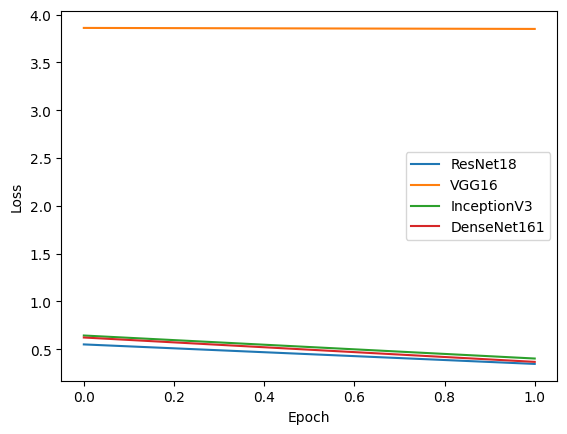

In [14]:
plt.plot(resnet_loss, label='ResNet18')
plt.plot(vgg_loss, label='VGG16')
plt.plot(inception_loss, label='InceptionV3')
plt.plot(dense_loss, label='DenseNet161')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [15]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['ResNet18','VGG16','InceptionV3','DenseNet161'],
    'Final Loss': [
        resnet_loss[-1],
        vgg_loss[-1],
        inception_loss[-1],
        dense_loss[-1]
    ]
})

results

,Model,Final Loss
0,ResNet18,0.346936
1,VGG16,3.850729
2,InceptionV3,0.403363
3,DenseNet161,0.368388
